# BDTs to separate the signal from double charm backgrounds

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [2]:
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.utils import shuffle
from sklearn.model_selection import KFold

###  Loading the data and checking statistics

In [3]:
%%time

data_prefix = "root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged"
file_prefix = "rds_categfiltered"
eventtype_inclMC = "23903000"
eventtype_signal = "13563002"
polarities = [ "magdown", "magup"]

#18: Xc_signal_Ypis_displaced_fromBs_fromDs
#19: Xc_signal_Ypis_displaced_fromB0_fromDp
#20: Xc_signal_Ypis_displaced_fromBp_fromD0

def load_dataframes():
    rdf_signal = ROOT.RDataFrame("DecayTree", [ f"{data_prefix}/{file_prefix}_2012_{eventtype_signal}_{p}_rs_24.root" for p in polarities ])
    rdf_Xc_signal_Ypis_displaced_fromBs_fromDs = ROOT.RDataFrame("DecayTree", [ f"{data_prefix}/{file_prefix}_2012_{eventtype_inclMC}_{p}_rs_18.root" for p in polarities ])
    rdf_Xc_signal_Ypis_displaced_fromB0_fromDp = ROOT.RDataFrame("DecayTree", [ f"{data_prefix}/{file_prefix}_2012_{eventtype_inclMC}_{p}_rs_19.root" for p in polarities ])
    rdf_Xc_signal_Ypis_displaced_fromBp_fromD0 = ROOT.RDataFrame("DecayTree", [ f"{data_prefix}/{file_prefix}_2012_{eventtype_inclMC}_{p}_rs_20.root" for p in polarities ])
   
    return (rdf_signal, rdf_Xc_signal_Ypis_displaced_fromBs_fromDs, rdf_Xc_signal_Ypis_displaced_fromB0_fromDp, rdf_Xc_signal_Ypis_displaced_fromBp_fromD0)

# Checking variables for a specific category
#------------------------------------------------------------------------------
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

CPU times: user 13 µs, sys: 3 µs, total: 16 µs
Wall time: 21.7 µs


In [4]:
(rdf_signal, rdf_disp_BsDs, rdf_disp_B0Dp, rdf_disp_BpD0) = load_dataframes()
# Uncomments to list columns in the ntuple
[ str(c) for c in rdf_signal.GetColumnNames() if str(c).startswith("Y_0_40_nc_max")]

['Y_0_40_nc_maxCL',
 'Y_0_40_nc_maxPt_PT',
 'Y_0_40_nc_maxPt_PX',
 'Y_0_40_nc_maxPt_PY',
 'Y_0_40_nc_maxPt_PZ']

In [5]:
#Below are the variables used fir the clssification in TMVA
"""
[lben@lxplus730 ConfrontoBDTCB]$ grep AddVariable  TMVAClassification.c | grep -v '//' | cut -d'"' -f2
Y_0_40_nc_mult
Y_0_20_cc_mult
Y_0_20_cc_PZ
Y_0_30_nc_PZ
Y_0_40_nc_PZ
Y_0_40_nc_maxPt_PT
min_m2pi
max_m2pi
missing_mass_2
B_M
log(abs(PBsn))
log(abs(PBv/B_P))
log(abs(PBvn/B_P))
log(abs((PBsn-PBvn)/PBvn))
log(sqrt(abs(mDs2vn)))
log(Y_PE)
BDT_Iso
B_pT_Bdir
Y_BPVVDR
missing_pY_mass
Y_correctedMass
"""

used_base_columns = [
"Y_0_40_nc_mult",
"Y_0_20_cc_mult",
"Y_0_20_cc_PZ",
"Y_0_30_nc_PZ",
"Y_0_40_nc_PZ",
"Y_0_40_nc_maxPt_PT",
"min_m2pi",
"max_m2pi",
"missing_mass_2",
"B_M",
# log(abs(PBsn))
# log(abs(PBv/B_P))
# log(abs(PBvn/B_P))
# log(abs((PBsn-PBvn)/PBvn))
# log(sqrt(abs(mDs2vn)))
# log(Y_PE)
"BDT_Iso",
"B_pT_Bdir",
"Y_BPVVDR",
"missing_pY_mass",
"Y_correctedMass", ]

cache_columns = used_base_columns + [
    "PBsn", "PBv", "B_P", "PBvn", "mDs2vn", "Y_PE"]

In [6]:
%%time

def load_df(rdf, signal = 0):
    df = pd.DataFrame(rdf.Cache(cache_columns).AsNumpy())
    df["log(abs(PBsn))"] = np.log(np.abs(df["PBsn"]))
    df["log(abs(PBv/B_P))"] = np.log(np.abs(df["PBv"] / df["B_P"]))
    df["log(abs(PBvn/B_P))"] = np.log(np.abs(df["PBvn"] / df["B_P"]))
    df["log(abs((PBsn-PBvn)/PBvn))"] = np.log(np.abs((df["PBsn"] - df["PBvn"]) / df["PBvn"]))
    df["log(sqrt(abs(mDs2vn)))"] = np.log(np.sqrt(np.abs(df["mDs2vn"])))
    df["log(Y_PE)"] = np.log(df["Y_PE"]) 
    df["signal"] = signal
    df["diff_m2pi"] = df["max_m2pi"] - df["min_m2pi"]
    return df

df_signal = load_df(rdf_signal, 1)
df_disp_BsDs = load_df(rdf_disp_BsDs, 0)
df_disp_B0Dp = load_df(rdf_disp_B0Dp, 0)
df_disp_BpD0 = load_df(rdf_disp_BpD0, 0)

CPU times: user 7.81 s, sys: 305 ms, total: 8.11 s
Wall time: 9.94 s


In [7]:
df_signal.shape, df_disp_BsDs.shape, df_disp_B0Dp.shape, df_disp_BpD0.shape

((30673, 29), (58754, 29), (63586, 29), (23609, 29))

# Classifier to separate signal and BsDs, B0Dp

### Data Preparation

In [8]:
# Concatenate and shuffle the backgrounds
df_background = pd.concat([df_disp_BsDs, df_disp_B0Dp, df_disp_BpD0], axis=0)
df_background= shuffle(df_background)

# To have equal samples of background and signal
#df_background = df_background.head(df_signal.shape[0])
df = pd.concat([df_signal,df_background], axis=0)
df = shuffle(df, random_state=42)

### Columns of interest

In [9]:
train_columns = [
"Y_0_40_nc_mult",
"Y_0_20_cc_mult",
"Y_0_20_cc_PZ",
"Y_0_30_nc_PZ",
"Y_0_40_nc_PZ",
"Y_0_40_nc_maxPt_PT",
"min_m2pi",
"max_m2pi",
"missing_mass_2",
"B_M",
"log(abs(PBsn))",
"log(abs(PBv/B_P))",
"log(abs(PBvn/B_P))",
"log(abs((PBsn-PBvn)/PBvn))",
"log(sqrt(abs(mDs2vn)))",
"log(Y_PE)",
"BDT_Iso",
"B_pT_Bdir",
"Y_BPVVDR",
"missing_pY_mass",
"Y_correctedMass"]

### Split the dataset in training and test sets

In [10]:
def train_classifier(Xtrain, ytrain, Xtest, ytest, scale_pos_weight, eval_metric='logloss'):
    ''' Train the classifier on the specified set'''
    
    # Apply a standard scaler to ease the training
    from sklearn import preprocessing
    scaler = preprocessing.StandardScaler().fit(Xtrain)
    Xtrain_scaled = scaler.transform(Xtrain)
    Xtest_scaled = scaler.transform(Xtest)
    
   
    # Create the classifier
    model = xgb.XGBClassifier( eval_metric=eval_metric, #eval_metric='logloss', 
                          n_estimators=200, eta=0.03, scale_pos_weight=scale_pos_weight)
    xgbclass = make_pipeline(scaler, model)

    evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
    model.fit(Xtrain_scaled, ytrain, eval_set=evalset)
    return model, xgbclass, scaler
    

def plot_eval_results(model, eval_metric='logloss'):
    results = model.evals_result()
    # plot learning curves
    plt.figure()
    plt.plot(results['validation_0'][eval_metric], label='train')
    plt.plot(results['validation_1'][eval_metric], label='test')
    plt.legend()
    plt.show()


def accuracy(xgbclass, Xtest, ytest):
    yscore = xgbclass.predict_proba(Xtest)
    ypred = xgbclass.predict(Xtest)
    accuracy = accuracy_score(ytest, ypred)
    print('Accuracy: %.3f' % accuracy)
    return accuracy

def plot_roc_curve(xgbclass, Xtest, ytest):
    # Roc curve
    yscore = xgbclass.predict_proba(Xtest)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

    # ROC curve 
    # RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
    fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
    roc_auc = auc(fpr, tpr)
    ax2.plot(1 - fpr, tpr)
    ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
    print(roc_auc)

    # Classifier output
    ax1.set_title(f"XGBoost Classifier output")
    t = 'step'
    n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
    ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
    ax1.legend()

def plot_roc_curve_list(xgbclass_list, Xtest_list, ytest_list):
    data = zip(Xtest_list, ytest_list)
    for i, (Xtest, ytest) in enumerate(data):
        yscore = xgbclass.predict_proba(Xtest)
        fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
        roc_auc = auc(fpr, tpr)
        plt.plot(1 - fpr, tpr, label=f"Fold {i}")
    plt.title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
    plt.legend()

    
def confusion_matrix(xgbclass, Xtest, ytest):
    # Confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    ypred = xgbclass.predict(Xtest)
    #Xtest_scaled = xgbclass.steps[0][1].transform(Xtest)
    confusion_matrix(ytest, ypred)
    class_names = [ "background", "signal"]
    ConfusionMatrixDisplay.from_estimator(
            xgbclass,
            Xtest,
            ytest,
            display_labels = class_names,
            cmap=plt.cm.Blues,
            normalize=None,
        )

In [12]:
# from sklearn.model_selection import train_test_split
# train, test = train_test_split(df, test_size=0.2)

xgbclass_list = []
Xtest_list = [] 
ytest_list = []
eval_metric = 'logloss'

kf = KFold(n_splits=2, shuffle=True) 
for train_index, test_index in kf.split(df):
    train_index, test_index = list(kf.split(df))[0]
    print(len(train_index))
    # Create the data set
    train = df.iloc[train_index]
    test = df.iloc[test_index]
    print(train.columns.values)
    Xtrain = train[train_columns]
    ytrain = train["signal"]
    Xtest = test[train_columns]
    ytest = test["signal"]

    # Ratio background to noise, used to set the weight on the signal samples in the training
    ratio = len(train[train['signal']==0]) / len(train[train['signal']==1])
    print("==============> ", ratio)
    res, xgbclass, scaler = train_classifier(Xtrain, ytrain, Xtest, ytest, ratio, eval_metric=eval_metric)
    xgbclass_list.append(xgbclass)
    Xtest_list.append(Xtest)
    ytest_list.append(ytest)

88311
['BDT_Iso' 'B_M' 'B_P' 'B_pT_Bdir' 'PBsn' 'PBv' 'PBvn' 'Y_0_20_cc_PZ'
 'Y_0_20_cc_mult' 'Y_0_30_nc_PZ' 'Y_0_40_nc_PZ' 'Y_0_40_nc_maxPt_PT'
 'Y_0_40_nc_mult' 'Y_BPVVDR' 'Y_PE' 'Y_correctedMass' 'mDs2vn' 'max_m2pi'
 'min_m2pi' 'missing_mass_2' 'missing_pY_mass' 'log(abs(PBsn))'
 'log(abs(PBv/B_P))' 'log(abs(PBvn/B_P))' 'log(abs((PBsn-PBvn)/PBvn))'
 'log(sqrt(abs(mDs2vn)))' 'log(Y_PE)' 'signal' 'diff_m2pi']
==============>  4.731131157115971
[0]	validation_0-logloss:0.67875	validation_1-logloss:0.67885
[1]	validation_0-logloss:0.66517	validation_1-logloss:0.66537
[2]	validation_0-logloss:0.65227	validation_1-logloss:0.65259
[3]	validation_0-logloss:0.64011	validation_1-logloss:0.64052
[4]	validation_0-logloss:0.62847	validation_1-logloss:0.62900
[5]	validation_0-logloss:0.61735	validation_1-logloss:0.61803
[6]	validation_0-logloss:0.60686	validation_1-logloss:0.60770
[7]	validation_0-logloss:0.59671	validation_1-logloss:0.59765
[8]	validation_0-logloss:0.58711	validation_1-logloss:0

[123]	validation_0-logloss:0.29085	validation_1-logloss:0.30251
[124]	validation_0-logloss:0.29032	validation_1-logloss:0.30204
[125]	validation_0-logloss:0.28980	validation_1-logloss:0.30157
[126]	validation_0-logloss:0.28924	validation_1-logloss:0.30107
[127]	validation_0-logloss:0.28869	validation_1-logloss:0.30057
[128]	validation_0-logloss:0.28813	validation_1-logloss:0.30008
[129]	validation_0-logloss:0.28763	validation_1-logloss:0.29965
[130]	validation_0-logloss:0.28703	validation_1-logloss:0.29910
[131]	validation_0-logloss:0.28642	validation_1-logloss:0.29859
[132]	validation_0-logloss:0.28597	validation_1-logloss:0.29820
[133]	validation_0-logloss:0.28544	validation_1-logloss:0.29771
[134]	validation_0-logloss:0.28481	validation_1-logloss:0.29717
[135]	validation_0-logloss:0.28434	validation_1-logloss:0.29675
[136]	validation_0-logloss:0.28383	validation_1-logloss:0.29634
[137]	validation_0-logloss:0.28336	validation_1-logloss:0.29594
[138]	validation_0-logloss:0.28267	valid

[45]	validation_0-logloss:0.39840	validation_1-logloss:0.40421
[46]	validation_0-logloss:0.39566	validation_1-logloss:0.40156
[47]	validation_0-logloss:0.39295	validation_1-logloss:0.39893
[48]	validation_0-logloss:0.39035	validation_1-logloss:0.39641
[49]	validation_0-logloss:0.38774	validation_1-logloss:0.39389
[50]	validation_0-logloss:0.38530	validation_1-logloss:0.39158
[51]	validation_0-logloss:0.38275	validation_1-logloss:0.38911
[52]	validation_0-logloss:0.38031	validation_1-logloss:0.38675
[53]	validation_0-logloss:0.37774	validation_1-logloss:0.38428
[54]	validation_0-logloss:0.37541	validation_1-logloss:0.38205
[55]	validation_0-logloss:0.37325	validation_1-logloss:0.37999
[56]	validation_0-logloss:0.37096	validation_1-logloss:0.37777
[57]	validation_0-logloss:0.36887	validation_1-logloss:0.37580
[58]	validation_0-logloss:0.36688	validation_1-logloss:0.37392
[59]	validation_0-logloss:0.36469	validation_1-logloss:0.37185
[60]	validation_0-logloss:0.36264	validation_1-logloss:

[174]	validation_0-logloss:0.26730	validation_1-logloss:0.28327
[175]	validation_0-logloss:0.26696	validation_1-logloss:0.28300
[176]	validation_0-logloss:0.26663	validation_1-logloss:0.28270
[177]	validation_0-logloss:0.26620	validation_1-logloss:0.28234
[178]	validation_0-logloss:0.26595	validation_1-logloss:0.28213
[179]	validation_0-logloss:0.26548	validation_1-logloss:0.28177
[180]	validation_0-logloss:0.26520	validation_1-logloss:0.28157
[181]	validation_0-logloss:0.26487	validation_1-logloss:0.28130
[182]	validation_0-logloss:0.26461	validation_1-logloss:0.28112
[183]	validation_0-logloss:0.26431	validation_1-logloss:0.28089
[184]	validation_0-logloss:0.26375	validation_1-logloss:0.28045
[185]	validation_0-logloss:0.26350	validation_1-logloss:0.28024
[186]	validation_0-logloss:0.26307	validation_1-logloss:0.27990
[187]	validation_0-logloss:0.26275	validation_1-logloss:0.27962
[188]	validation_0-logloss:0.26235	validation_1-logloss:0.27933
[189]	validation_0-logloss:0.26208	valid

In [13]:
for ytest in ytest_list:
    print(len(ytest[ytest == 1]))


15264
15361


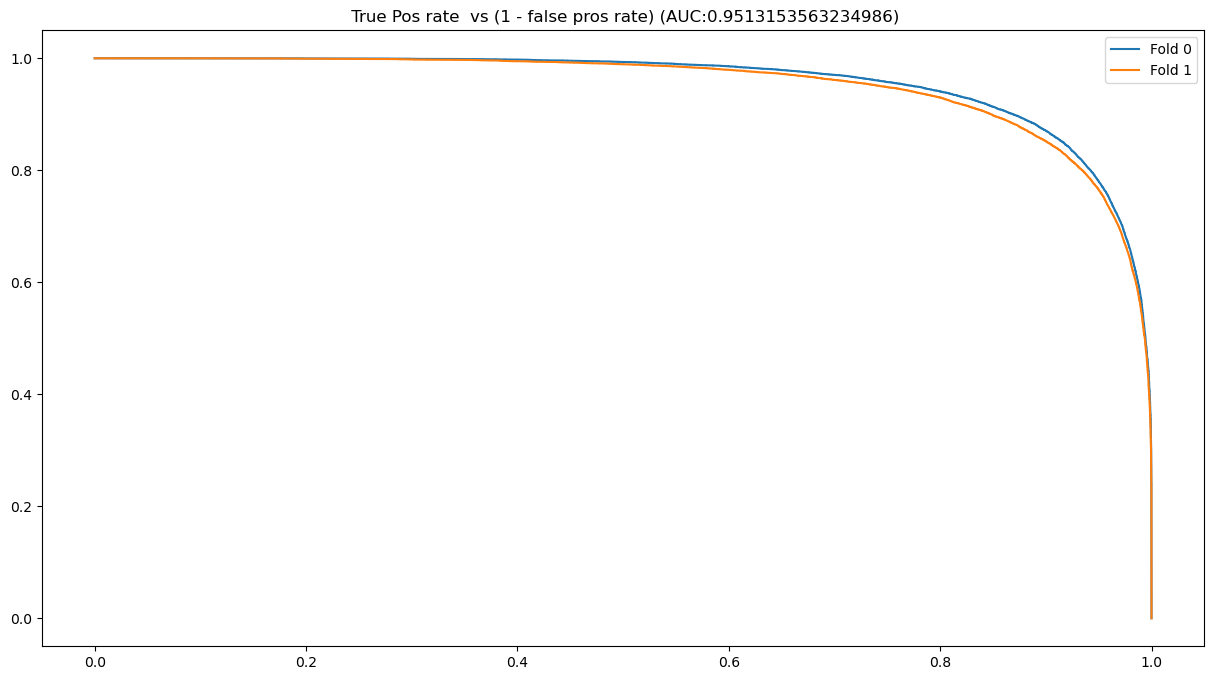

In [14]:
plot_roc_curve_list(xgbclass_list, Xtest_list, ytest_list)

In [15]:
xgbclass.steps[1][1]

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False, eta=0.03,
              eval_metric='logloss', feature_types=None, gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.0299999993,
              max_bin=256, max_cat_threshold=64, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=200,
              n_jobs=0, num_parallel_tree=1, predictor='auto', ...)

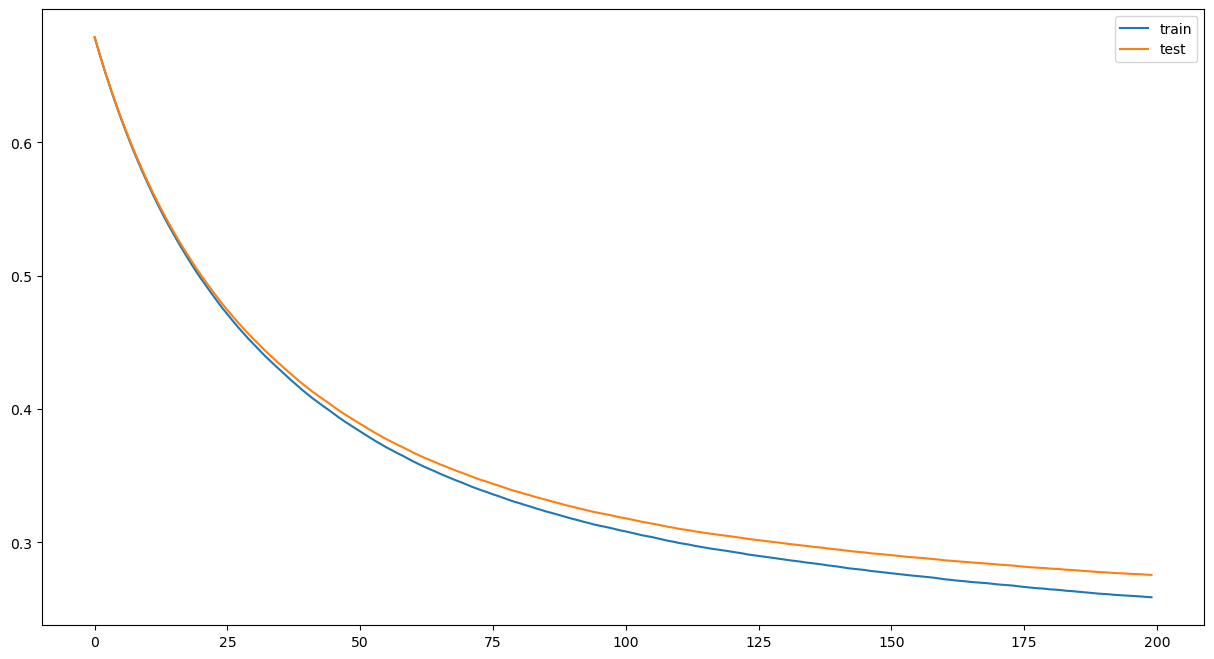

Accuracy: 0.888
0.9501538278290083


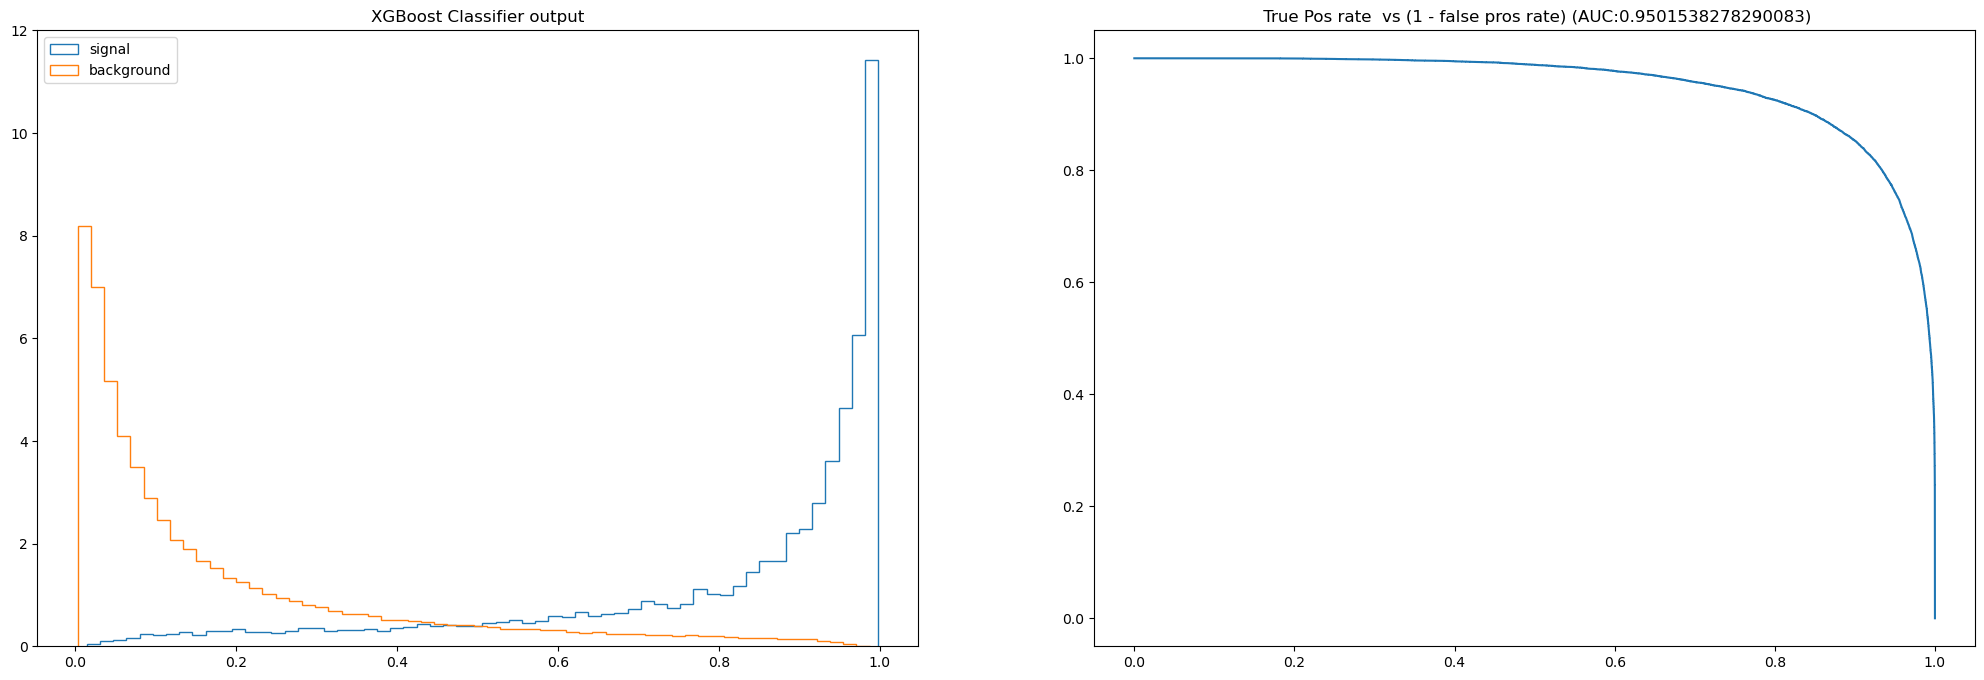

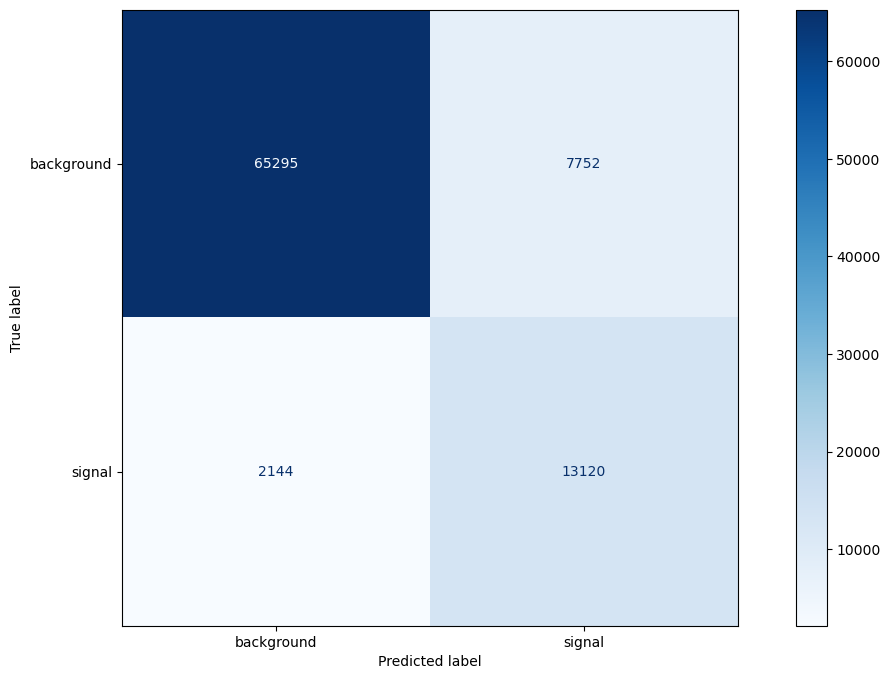

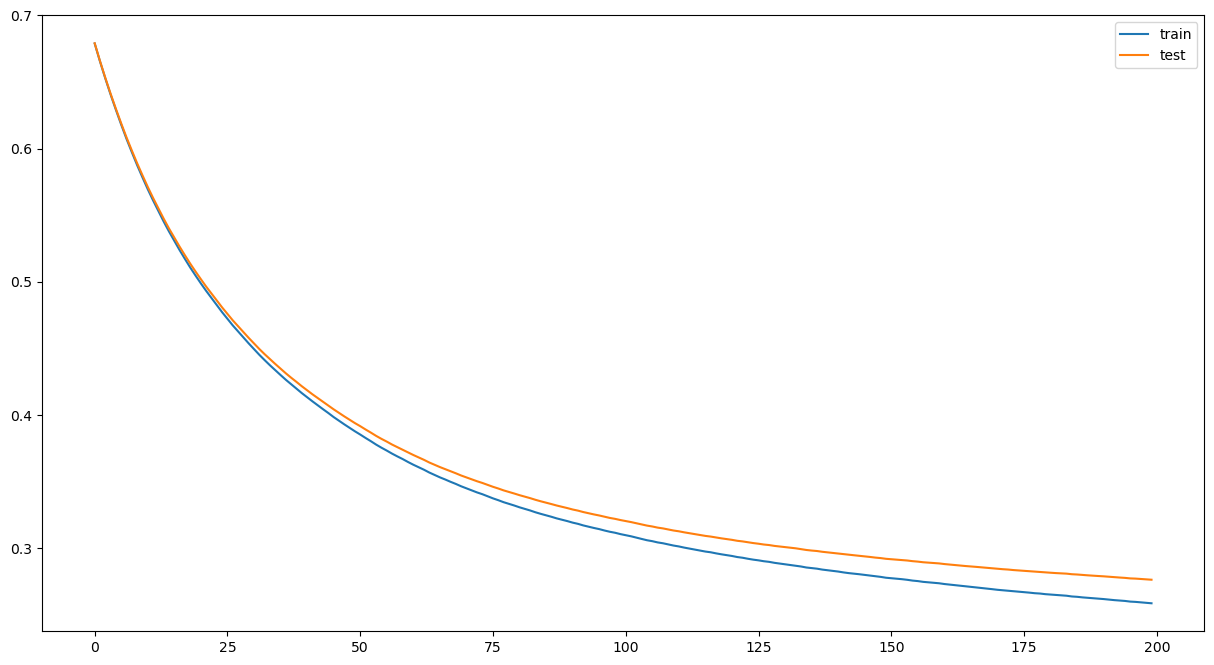

Accuracy: 0.888
0.9513153563234986


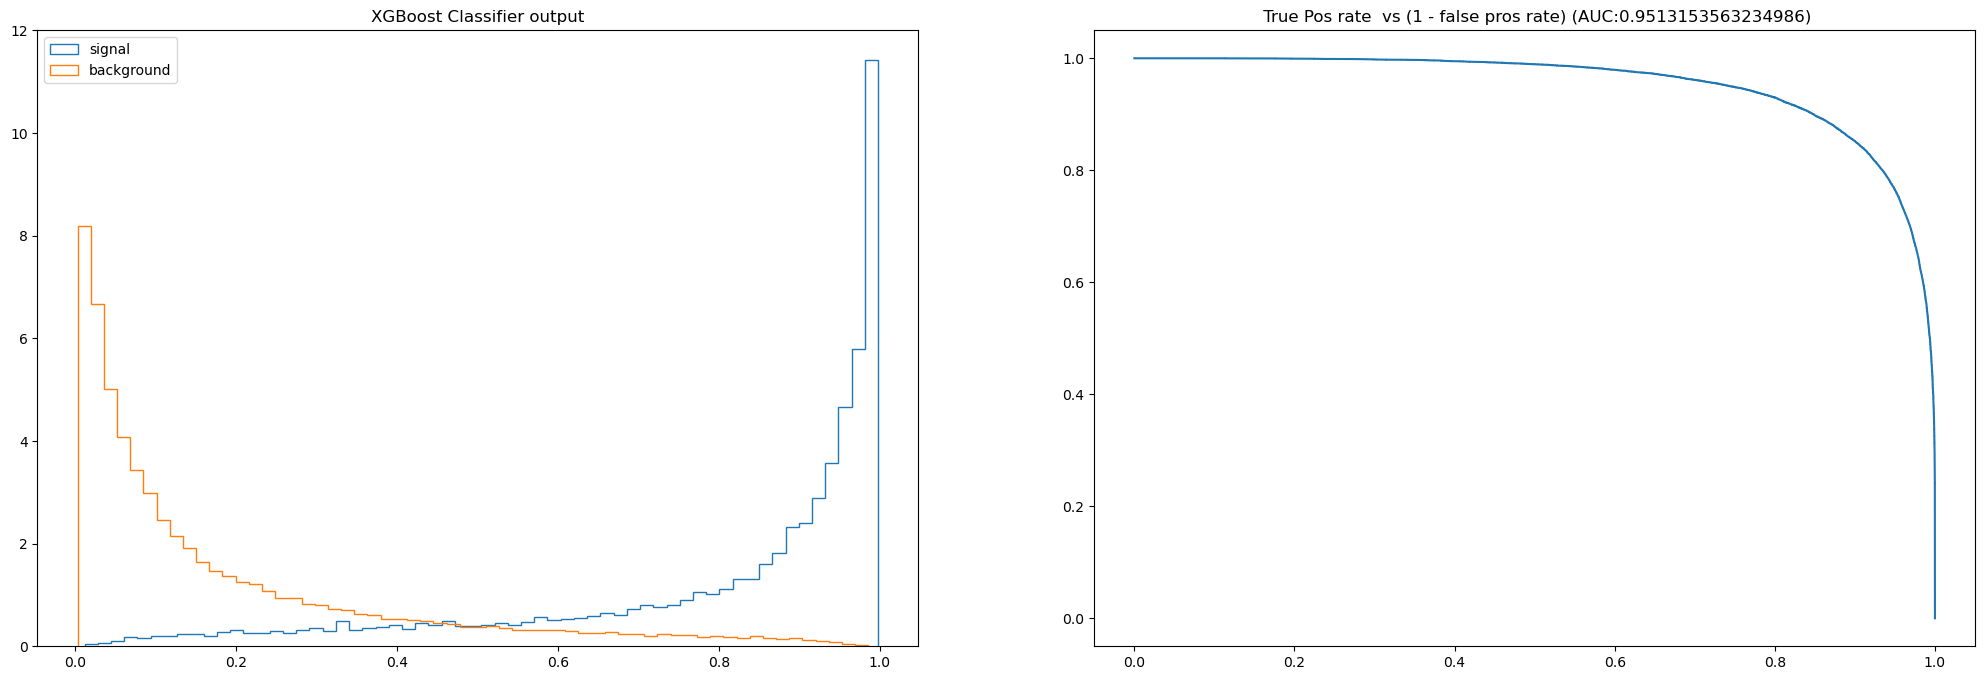

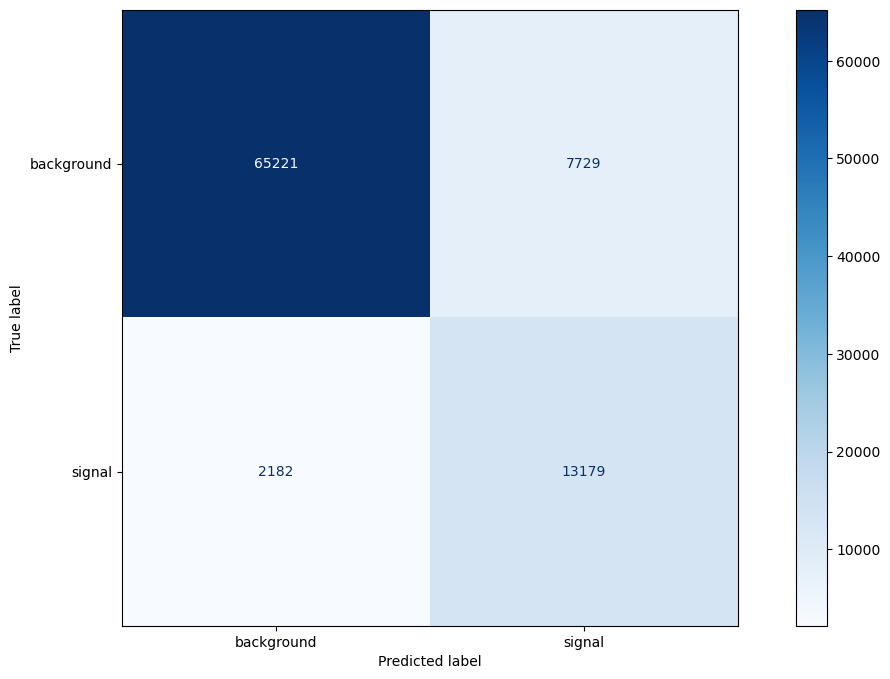

In [16]:
for i in range(len(xgbclass_list)):
    xgbclass = xgbclass_list[i]
    Xtest = Xtest_list[i]
    ytest = ytest_list[i]

    plot_eval_results(xgbclass.steps[1][1], eval_metric)
    accuracy(xgbclass, Xtest, ytest)
    plot_roc_curve(xgbclass, Xtest, ytest)
    confusion_matrix(xgbclass, Xtest, ytest)

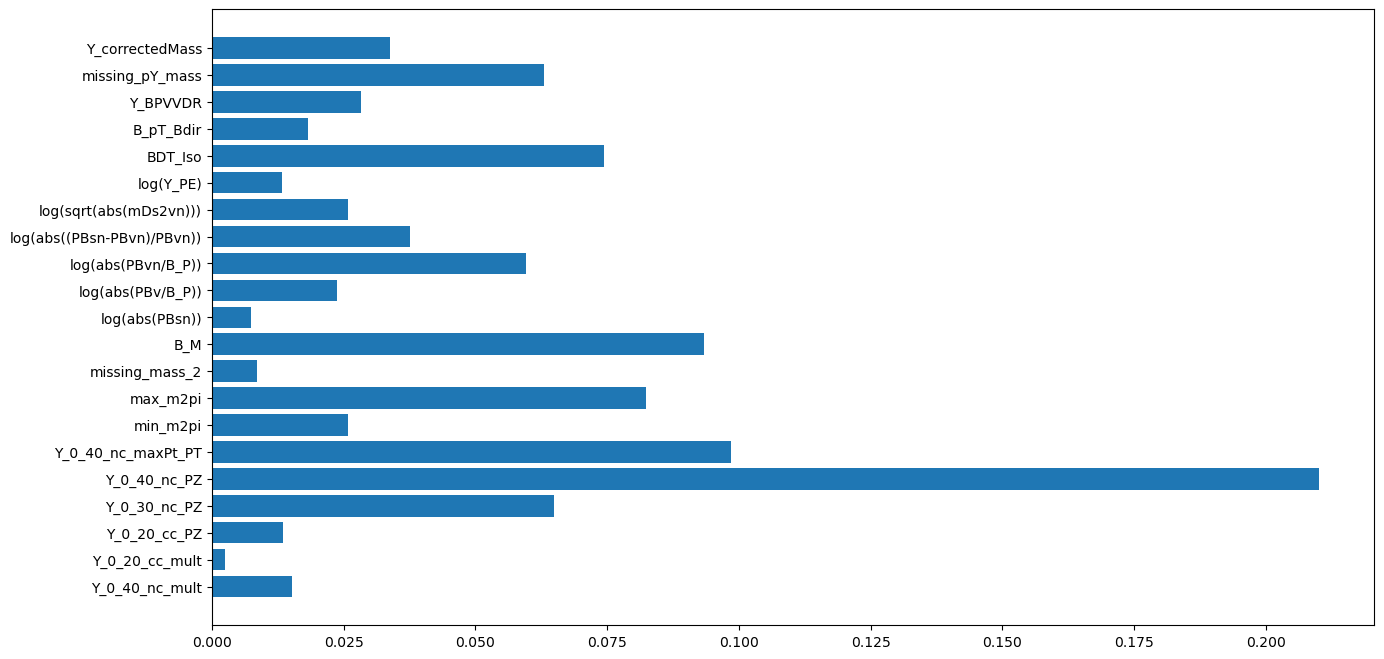

In [17]:
xgbclass = xgbclass_list[0]
plt.barh(Xtest_list[0].columns, xgbclass.steps[1][1].feature_importances_);

# Optimizing the parameters

In [18]:
parameters = {
    'learning_rate': [0.1, 0.05],#, 0.05],
    'max_depth': range (2, 5),
    'n_estimators': [ 60, 20,],# 500, 1000 ],
    'num_boost_round': [60, 250]  
}

c.f. https://neptune.ai/blog/xgboost-everything-you-need-to-know

In [25]:
xgbclass.steps[1][1]

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False, eta=0.03,
              eval_metric='logloss', feature_types=None, gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.0299999993,
              max_bin=256, max_cat_threshold=64, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=200,
              n_jobs=0, num_parallel_tree=1, predictor='auto', ...)

In [26]:
from sklearn.model_selection import GridSearchCV
model = xgbclass.steps[1][1]
grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameters,
    scoring = 'roc_auc',
    n_jobs = 8,
    cv = 2,
    verbose=10
)

In [28]:
res = grid_search.fit(Xtrain, ytrain)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
[15:09:24] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1667849527992/work/src/learner.cc:767: 
Parameters: { "num_boost_round" } are not used.



In [31]:
results = pd.DataFrame(grid_search.cv_results_)

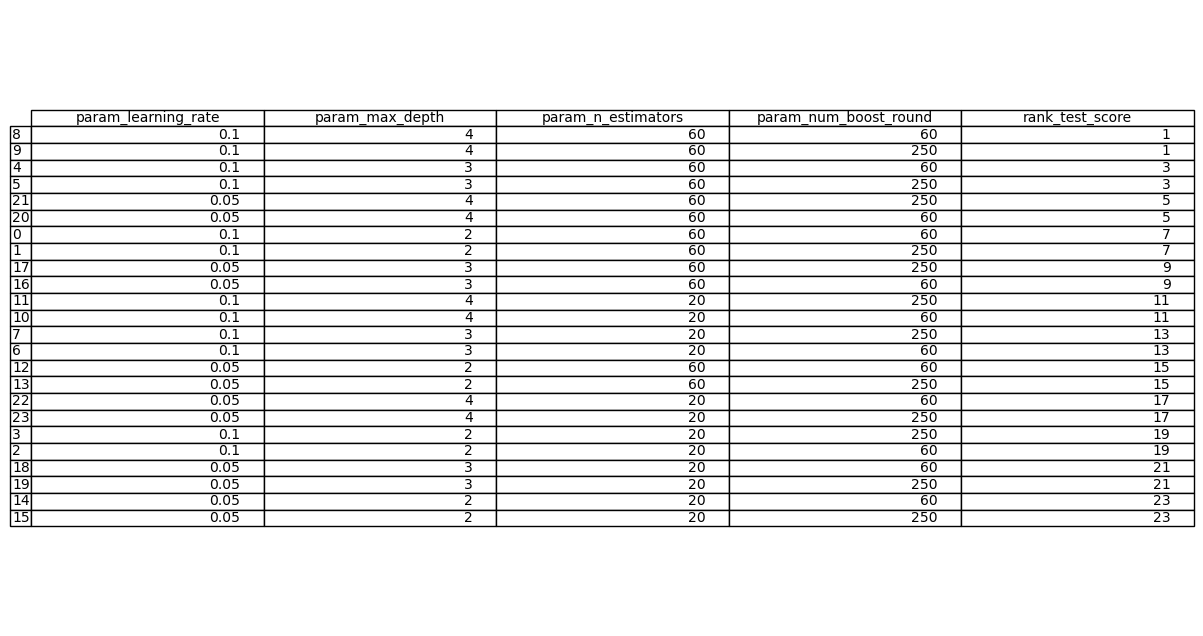

In [57]:
cols = [ c for c in results.columns if c.startswith("param_") or c == "rank_test_score"]
fig= plt.figure()
plt.tick_params(axis='x', which='both', bottom=False,
            top=False, labelbottom=False)  
plt.tick_params(axis='y', which='both', right=False,
                left=False, labelleft=False)
for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

pd.plotting.table(plt.gca(), results[cols].sort_values(["rank_test_score"]), loc="center");


In [54]:
type(t)

matplotlib.table.Table

In [35]:
results.sort_values(["rank_test_score"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_num_boost_round,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
8,7.794835,0.028202,0.070724,0.002600,0.1,4,60,60,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.943470,0.945694,0.944582,0.001112,1
9,7.700114,0.038121,0.071757,0.002618,0.1,4,60,250,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.943470,0.945694,0.944582,0.001112,1
4,5.861244,0.015271,0.062850,0.000714,0.1,3,60,60,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.938957,0.939968,0.939463,0.000506,3
5,5.840415,0.036798,0.063913,0.002860,0.1,3,60,250,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.938957,0.939968,0.939463,0.000506,3
21,7.205115,0.116510,0.044798,0.003722,0.05,4,60,250,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.934299,0.935537,0.934918,0.000619,5
20,7.306337,0.057041,0.045139,0.000733,0.05,4,60,60,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.934299,0.935537,0.934918,0.000619,5
0,3.805976,0.036349,0.056787,0.000405,0.1,2,60,60,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.932196,0.932533,0.932365,0.000168,7
1,3.780486,0.093480,0.056635,0.002448,0.1,2,60,250,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.932196,0.932533,0.932365,0.000168,7
17,6.291053,0.079451,0.069776,0.005766,0.05,3,60,250,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.927320,0.929734,0.928527,0.001207,9
16,6.109044,0.039077,0.064130,0.002872,0.05,3,60,60,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.927320,0.929734,0.928527,0.001207,9


In [ ]:
# How checking the prediction...
ypred_custom = (yscore[:,1] > yscore[:,0])  
ypred[ ypred != ypred_custom ].shape


In [ ]:
ytest[ytest == 1]# 5314
4434 + 880

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, ypred)

In [ ]:
sum(ytest == ypred)

In [ ]:
sum(ytest != ypred)

# Checking correlation of B_Y_SEP with other variables

In [ ]:
scor = df_signal[['max_m2pi', 'B_Y_SEP', 'Y_M', 'missing_mass_2', 'BDT_Iso', 'B_pT_Bdir', 'log(abs((PBsn-PBvn)/PBvn))', 'Y_0_20_nc_maxPt_PT']].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds);

In [ ]:
scor = df_disp_B0Dp[['max_m2pi', 'B_Y_SEP', 'Y_M', 'missing_mass_2', 'BDT_Iso', 'B_pT_Bdir', 'log(abs((PBsn-PBvn)/PBvn))', 'Y_0_20_nc_maxPt_PT']].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds);

In [ ]:
scor = df_disp_BsDs[['max_m2pi', 'B_Y_SEP', 'Y_M', 'missing_mass_2', 'BDT_Iso', 'B_pT_Bdir', 'log(abs((PBsn-PBvn)/PBvn))', 'Y_0_20_nc_maxPt_PT']].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds);